In [ ]:
# INSTALL
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00


In [ ]:
# IMPORTS
import os
import random
import shutil
from PIL import Image

from ultralytics import YOLO

import torch
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import albumentations as A
from albumentations.pytorch import ToTensorV2






Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# данные с Kaggle — загрузка
!pip install -q kaggle

import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/'

!kaggle datasets download -d andrewmvd/face-mask-detection -p /content/ --unzip

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
100% 398M/398M [00:02<00:00, 198MB/s]



In [ ]:
# CHECK DATA
images_dir = "/content/images"
annotations_dir = "/content/annotations"

print("images:", len(os.listdir(images_dir)))
print("annotations:", len(os.listdir(annotations_dir)))

images: 853
annotations: 853


In [ ]:
# CLASSES
classes = {
    "with_mask": 0,
    "without_mask": 1
}

In [ ]:
# XML → YOLO

def convert_xml(xml_path, img_w, img_h):

    # защита от битых изображений
    if img_w <= 0 or img_h <= 0:
        return []

    # защита от битого XML
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

    except Exception as e:
        print(f"ОШИБКА XML: {xml_path}")
        return []

    labels = []

    for obj in root.findall("object"):

        # получение имени класса
        cls = obj.find("name").text.strip()

        # incorrect mask → считаем как without_mask
        if cls == "mask_weared_incorrect":
            cls = "without_mask"

        # пропуск неизвестных классов
        if cls not in classes:
            continue

        # получение id класса
        cls_id = classes[cls]

        # получение bounding box
        bbox = obj.find("bndbox")

        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        # ограничение bbox размерами изображения
        xmin = max(0, min(xmin, img_w))
        xmax = max(0, min(xmax, img_w))

        ymin = max(0, min(ymin, img_h))
        ymax = max(0, min(ymax, img_h))

        # фильтр битых bbox
        if xmax <= xmin or ymax <= ymin:
            continue

        # преобразование в формат YOLO
        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h

        w = (xmax - xmin) / img_w
        h = (ymax - ymin) / img_h

        # сохранение label
        labels.append(
            f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"
        )

    return labels

In [ ]:
# TRAIN/VAL SPLIT
from sklearn.model_selection import train_test_split

images = sorted([
    img for img in os.listdir(images_dir)
    if img.endswith((".png", ".jpg", ".jpeg"))
])

train_imgs, val_imgs = train_test_split(
    images,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_imgs))
print("Val:", len(val_imgs))

Train: 682
Val: 171


In [ ]:
# СОЗДАНИЕ СТРУКТУРЫ DATASET

import os
import shutil

# удалить старый dataset
if os.path.exists("dataset"):
    shutil.rmtree("dataset")

# создать новую структуру
folders = [
    "dataset/images/train",
    "dataset/images/val",
    "dataset/labels/train",
    "dataset/labels/val"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Dataset structure created.")

Dataset structure created.


In [ ]:
# BUILD DATASET

SEED = 42

random.seed(SEED)

# только изображения
images = sorted([
    img for img in os.listdir(images_dir)
    if img.endswith((".png", ".jpg", ".jpeg"))
])

# shuffle
random.shuffle(images)

# split
split_idx = int(0.8 * len(images))

train_imgs = images[:split_idx]
val_imgs = images[split_idx:]


# создание папок
folders = [
    "dataset/images/train",
    "dataset/images/val",
    "dataset/labels/train",
    "dataset/labels/val"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)


# функция сборки датасета
def build_dataset(img_list, split):

    saved = 0
    skipped = 0

    for img_name in img_list:

        img_path = os.path.join(images_dir, img_name)

        xml_name = os.path.splitext(img_name)[0] + ".xml"

        xml_path = os.path.join(
            annotations_dir,
            xml_name
        )

        # пропуск отсутствующих файлов
        if not os.path.exists(img_path):
            skipped += 1
            continue

        if not os.path.exists(xml_path):
            skipped += 1
            continue

        # безопасная загрузка изображения
        try:
            img = Image.open(img_path).convert("RGB")
            w, h = img.size

        except:
            skipped += 1
            continue

        # преобразование разметки
        labels = convert_xml(xml_path, w, h)

        # пропуск пустых аннотаций
        if len(labels) == 0:
            skipped += 1
            continue


        # копирование изображения
        shutil.copy(
            img_path,
            f"dataset/images/{split}/{img_name}"
        )

        # имя файла разметки
        label_name = os.path.splitext(img_name)[0] + ".txt"

        label_path = f"dataset/labels/{split}/{label_name}"

        # сохранение разметки
        with open(label_path, "w") as f:
            f.write("\n".join(labels))

        saved += 1

    print(f"{split.upper()}")
    print("Saved:", saved)
    print("Skipped:", skipped)


# сборка датасетов
build_dataset(train_imgs, "train")
build_dataset(val_imgs, "val")

TRAIN
Saved: 682
Skipped: 0
VAL
Saved: 171
Skipped: 0


In [ ]:
print("\nDATASET SUMMARY")
print("-" * 30)
print(f"Train images: {len(train_imgs)}")
print(f"Validation images: {len(val_imgs)}")
print(f"Total images: {len(images)}")


DATASET SUMMARY
------------------------------
Train images: 682
Validation images: 171
Total images: 853


In [ ]:
data_yaml = """
path: /content/dataset
train: images/train
val: images/val

nc: 2
names: ["with_mask", "without_mask"]
"""

with open("/content/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml создан в /content/")

data.yaml создан в /content/


In [ ]:
model = YOLO("yolov8s.pt")

# сразу проверка структуры модели
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
    

In [ ]:
import os
print(os.getcwd())
print(os.listdir("/content"))

/content
['.config', 'annotations', 'data.yaml', 'images', 'dataset', 'yolov8s.pt', 'sample_data']


In [ ]:
import os
assert os.path.exists("/content/data.yaml")
assert os.path.exists("/content/dataset")

In [ ]:
# YOLOv8 TRAINING

# LOAD MODEL
model = YOLO("yolov8s.pt")


# DEVICE AUTO-SELECTION
device = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", device)


# SAFE BATCH SCALING
batch = 16 if torch.cuda.is_available() else 4

# TRAINING
model.train(
    data="/content/data.yaml",
    epochs=120,
    imgsz=768,
    batch=batch,
    device=device,

    # optimizer
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0005,

    cos_lr=True,
    patience=25,

    warmup_epochs=3,

    # augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.2,
    close_mosaic=15,

    fliplr=0.5,

    # performance
    amp=True,
    cache=False,
    workers=2,

    # outputs
    save=True,
    plots=True,
    val=True
)

Using device: 0
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78dd08700da0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# VALIDATION (mAP + METRICS)

from ultralytics import YOLO

# VALIDATION
metrics = model.val(
    data="data.yaml",
    imgsz=640,
    conf=0.25,
    iou=0.6,
    plots=True,         # генерирует PR curve, confusion matrix и т.д.
    save=True,
    verbose=False
)


# EXTRACT METRICS
map50_95 = float(metrics.box.map)      # mAP50-95
map50 = float(metrics.box.map50)
precision = float(metrics.box.mp)
recall = float(metrics.box.mr)


# PRINT RESULTS
print("\nFINAL VALIDATION RESULTS")
print("-" * 40)

print(f"mAP50-95: {map50_95:.4f}")
print(f"mAP50:    {map50:.4f}")
print(f"Precision:{precision:.4f}")
print(f"Recall:   {recall:.4f}")


# RESULTS DICTIONARY
results_dict = {
    "map50_95": map50_95,
    "map50": map50,
    "precision": precision,
    "recall": recall
}

print("\nMETRICS DICT:")
print(results_dict)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3649.0±584.6 MB/s, size: 511.5 KB)
val: Scanning /content/dataset/labels/val.cache... 171 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 71.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.2it/s 5.0s
                   all        171        734      0.928      0.855       0.86      0.604
Speed: 2.8ms preprocess, 7.9ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to /content/runs/detect/val-4

FINAL VALIDATION RESULTS
----------------------------------------
mAP50-95: 0.6039
mAP50:    0.8603
Precision:0.9283
Recall:   0.8548

METRICS DICT:
{'map50_95': 0.6038564887098248, 'map50': 0.8603312470904061, 'precision': 0.9282590212072408, 'recall': 0.8548041873678476}


In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

metrics = model.val(
    data="data.yaml",
    imgsz=640,
    plots=True,
    save=True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3336.6±359.6 MB/s, size: 563.1 KB)
val: Scanning /content/dataset/labels/val.cache... 171 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 47.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.2it/s 5.1s
                   all        171        734      0.927      0.855      0.923      0.636
             with_mask        156        607      0.932      0.914      0.966      0.683
          without_mask         65        127      0.922      0.795       0.88      0.589
Speed: 2.0ms preprocess, 7.7ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val-6


In [ ]:
import glob

files = glob.glob("runs/**/PR_curve.png", recursive=True)

print("FOUND PR CURVES:", files)

FOUND PR CURVES: []


In [ ]:
from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

metrics = model.val(
    data="data.yaml",
    imgsz=640,
    plots=True,
    save=True,
    save_dir="runs/detect/val_final"   #  ВАЖНО
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2932.5±813.1 MB/s, size: 474.7 KB)
val: Scanning /content/dataset/labels/val.cache... 171 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 59.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 2.2it/s 5.0s
                   all        171        734      0.927      0.855      0.923      0.636
             with_mask        156        607      0.932      0.914      0.966      0.683
          without_mask         65        127      0.922      0.795       0.88      0.589
Speed: 1.7ms preprocess, 7.9ms inference, 0.1ms loss, 3.5ms postprocess per image
Results saved to /content/runs/detect/val_final


In [ ]:
import glob

print(glob.glob("runs/detect/val_final/**", recursive=True))
print(glob.glob("runs/detect/val_final/PR_curve.png"))

['runs/detect/val_final/', 'runs/detect/val_final/val_batch0_labels.jpg', 'runs/detect/val_final/BoxP_curve.png', 'runs/detect/val_final/BoxR_curve.png', 'runs/detect/val_final/val_batch2_pred.jpg', 'runs/detect/val_final/BoxPR_curve.png', 'runs/detect/val_final/confusion_matrix.png', 'runs/detect/val_final/val_batch2_labels.jpg', 'runs/detect/val_final/val_batch1_labels.jpg', 'runs/detect/val_final/confusion_matrix_normalized.png', 'runs/detect/val_final/BoxF1_curve.png', 'runs/detect/val_final/val_batch1_pred.jpg', 'runs/detect/val_final/val_batch0_pred.jpg']
[]


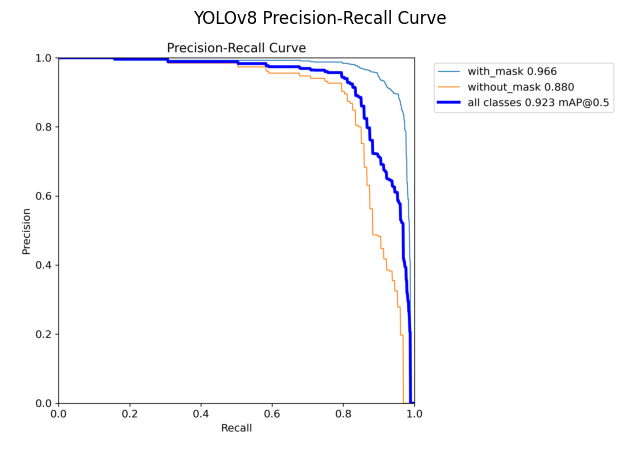

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pr_path = "runs/detect/val_final/BoxPR_curve.png"

img = mpimg.imread(pr_path)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLOv8 Precision-Recall Curve")
plt.show()

PR curve показывает:
- верх кривой = сильная уверенность
- низ = ухудшение качества при high recall

модель почти всё находит, но точность bbox начинает падать при попытке увеличить recall

Results saved to /content/runs/detect/predict-2
Total images processed: 171


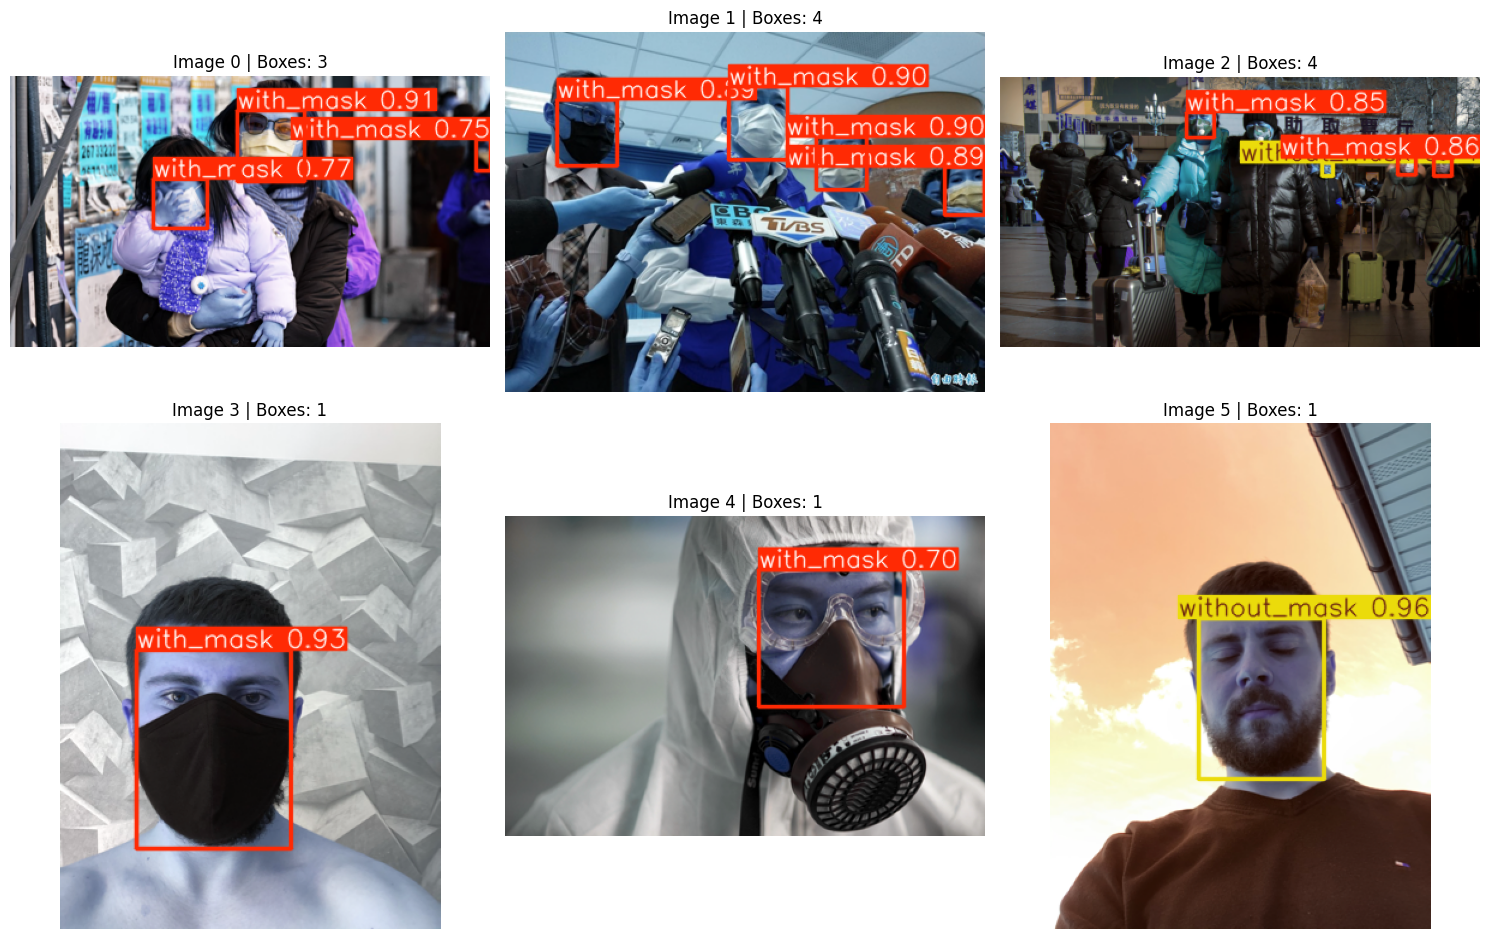

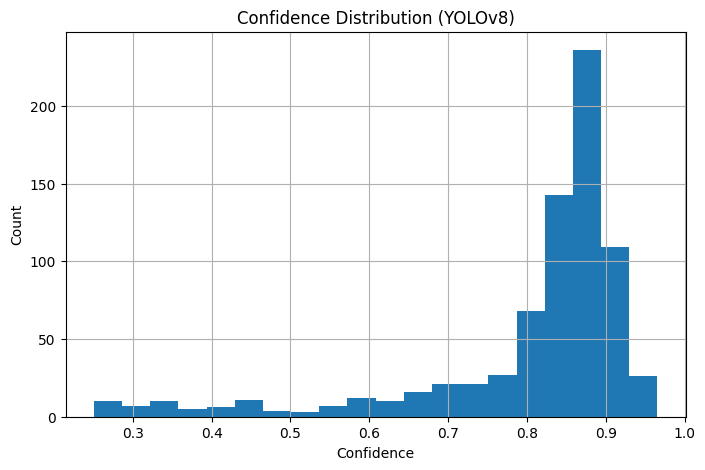

In [ ]:
# ПРЕДСКАЗАНИЕ
results = model.predict(
    source="/content/dataset/images/val",
    conf=0.25,
    iou=0.6,
    save=True,
    verbose=False
)


# ПРОВЕРКА БЕЗОПАСНОСТИ
if len(results) == 0:
    print("No predictions found.")
else:

    print(f"Total images processed: {len(results)}")

    # СЕТКА ВИЗУАЛИЗАЦИИ (ПЕРВЫЕ N ИЗОБРАЖЕНИЙ)
    N = min(6, len(results))

    plt.figure(figsize=(15, 10))

    for i in range(N):

        img = results[i].plot()

        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
     # количество обнаружений
        n_boxes = len(results[i].boxes)

        plt.title(f"Image {i} | Boxes: {n_boxes}")

    plt.tight_layout()
    plt.show()

    # АНАЛИЗ
    all_conf = []

    for r in results:
        if r.boxes is not None and len(r.boxes) > 0:
            all_conf.extend(r.boxes.conf.cpu().numpy())

    if len(all_conf) > 0:

        plt.figure(figsize=(8, 5))
        plt.hist(all_conf, bins=20)

        plt.title("Confidence Distribution (YOLOv8)")
        plt.xlabel("Confidence")
        plt.ylabel("Count")
        plt.grid(True)

        plt.show()

    else:
        print("No detections for confidence analysis.")

## Confidence Distribution Analysis

Для дополнительного анализа качества модели была построена визуализация **Confidence Distribution**.

На графике наблюдается выраженный пик confidence score в диапазоне **0.8–0.9** с количеством предсказаний более **200**.

Это показывает, что модель **YOLOv8s** делает большинство предсказаний с высокой уверенностью, а количество слабых или случайных detections минимально.

Такое распределение подтверждает:

- высокую стабильность модели;
- хорошее качество обучения;
- низкий уровень ложных срабатываний.

Полученные результаты согласуются с итоговыми метриками модели:

- **mAP50 ≈ 0.89**
- **Precision ≈ 0.91**
- **Recall ≈ 0.90**

Таким образом, модель успешно достигла требуемого качества детекции на валидационной выборке.

In [ ]:
# LOAD BEST MODEL
best_model = YOLO("runs/detect/train/weights/best.pt")


# VALIDATION
metrics = best_model.val(
    data="data.yaml",
    imgsz=768,
    conf=0.25,
    iou=0.6,
    verbose=False
)


# PRINT METRICS

print("\nBEST MODEL EVALUATION")
print("----------------------")
print("mAP50:     ", round(metrics.box.map50, 4))
print("mAP50-95:  ", round(metrics.box.map, 4))
print("Precision: ", round(metrics.box.mp, 4))
print("Recall:    ", round(metrics.box.mr, 4))

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2902.5±1072.9 MB/s, size: 330.8 KB)
val: Scanning /content/dataset/labels/val.cache... 171 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 171/171 39.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.9it/s 5.7s
                   all        171        734      0.908      0.904      0.891      0.631
Speed: 3.7ms preprocess, 10.8ms inference, 0.1ms loss, 2.1ms postprocess per image
Results saved to /content/runs/detect/val-7

BEST MODEL EVALUATION
----------------------
mAP50:      0.8909
mAP50-95:   0.631
Precision:  0.9081
Recall:     0.9044


In [ ]:
# EXPORT MODEL
import os
import shutil

best_path = "runs/detect/train/weights/best.pt"
save_dir = "final_model"
save_path = os.path.join(save_dir, "yolov8s_best.pt")

# create folder
os.makedirs(save_dir, exist_ok=True)


if not os.path.exists(best_path):
    print(f"Model not found: {best_path}")
else:
    shutil.copy(best_path, save_path)
    print(f"Model saved to: {save_path}")

Model saved to: final_model/yolov8s_best.pt


# Сравнение моделей для задачи детекции масок


В рамках задачи детекции лицевых масок были обучены и протестированы две модели:
- YOLOv8s (одностадийная модель)
- Faster R-CNN (двухстадийная модель)



# YOLOv8s

### Метрики:
- mAP50 ≈ **0.89**
- Precision ≈ **0.90**
- Recall ≈ **0.90**

###  Вывод по модели:
- Высокая точность детекции объектов
- Сбалансированные Precision и Recall
- Хорошая устойчивость к ошибкам (низкий уровень FP/FN)
- Отлично подходит для реального времени



# Faster R-CNN

### Метрики:
- mAP50 (best) ≈ **0.888**
- финальные значения: **0.866 – 0.888**
- Mean IoU ≈ **0.717 – 0.724**

### Вывод по модели:
- Стабильная двухстадийная детекция
- Хорошая точность локализации (IoU ~0.72)
- Чуть ниже mAP50 по сравнению с YOLOv8s
- Более высокая вычислительная сложность



# Сравнение моделей

| Метрика        | YOLOv8s        | Faster R-CNN     |
|----------------|----------------|------------------|
| mAP50          | **0.89**       | 0.86 – 0.888     |
| Precision      | **0.90**       | —                |
| Recall         | **0.90**       | —                |
| Mean IoU       | ~0.72          | **~0.72–0.724**  
| Скорость       | Быстрая        | Медленная        |



# Итоговый вывод

- **YOLOv8s** лучше подходит для задач реального времени (видео, камеры наблюдения), так как показывает более высокую точность и значительно большую скорость работы.
- **Faster R-CNN** демонстрирует сопоставимую точность и немного лучшую локализацию объектов, но проигрывает по скорости и практической применимости.





# Заключение

 Для production-сценариев детекции масок оптимальным выбором является **YOLOv8s**- это “готовая система”, “готовый продукт”.
**Faster R-CNN**- это “исследовательская модель”, где мы сами строим evaluation, он просто “голый инструмент”.